# NES EDA Mockup (30 Visualizations)

This notebook is a reusable EDA template for DANO/NES-style projects.

- Data source: `Base_nes.csv`
- Visualization library: `seaborn`
- Style: matched to `hypotesis_final.ipynb` (font + palette)

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib.font_manager import fontManager, FontProperties

DATA_PATH = "/Users/royalmustaches/Documents/Programming/Dano/DANO_ITMO_2026/Datasets/Base_nes.csv"

# Style from hypotesis_final.ipynb
PALETTE = ["#5e17eb", "#ff6b6b", "#00c49a"]
COLORS = ["#5e17eb", "#ffffff", "#ff0000"]

FONT_CANDIDATES = [
    "/Users/royalmustaches/Documents/Programming/Dano/DANO_ITMO_2026/HSE_FONTS_FOR_GRAPHS_copy/HSESlab-Regular.ttf",
    "/Users/royalmustaches/Documents/Programming/Dano/DANO_NES_2026/HSE_FONTS_FOR_GRAPHS/HSESlab-Regular.ttf",
    "/Users/royalmustaches/Documents/Programming/Dano/Practice/Organization/Fonts_for_projects/HSESlab-Regular.ttf",
]

FONT_NAME = "DejaVu Sans"
for font_path in FONT_CANDIDATES:
    if os.path.exists(font_path):
        fontManager.addfont(font_path)
        FONT_NAME = FontProperties(fname=font_path).get_name()
        break

sns.set_theme(style="whitegrid", font=FONT_NAME, context="notebook", palette=PALETTE)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["grid.linestyle"] = "--"

PRIMARY = "#5e17eb"
SECONDARY = "#ff6b6b"
ACCENT = "#00c49a"

In [3]:
df = pd.read_csv(DATA_PATH)

# Basic cleaning / typing
for col in ["salary", "experience", "birthday", "inner_info_fullness_rate"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

for col in ["date_publish", "date_creation", "date_last_updated", "date_time_publish", "time_publish"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# Time features
if "date_publish" in df.columns:
    df["publish_weekday"] = df["date_publish"].dt.day_name()
    df["publish_month"] = df["date_publish"].dt.month

if "date_time_publish" in df.columns:
    df["publish_hour"] = df["date_time_publish"].dt.hour

# Capped numeric copy for stable charts
plot_df = df.copy()
plot_df = plot_df[(plot_df["salary"].isna()) | (plot_df["salary"] >= 0)]
plot_df = plot_df[(plot_df["experience"].isna()) | (plot_df["experience"] >= 0)]

# Hard caps to reduce outlier domination in EDA visuals
plot_df.loc[plot_df["experience"] > 60, "experience"] = np.nan
plot_df.loc[plot_df["salary"] > plot_df["salary"].quantile(0.995), "salary"] = np.nan

plot_df["log_salary"] = np.log1p(plot_df["salary"])

print(f"Shape: {df.shape}")
print(f"Font in use: {FONT_NAME}")

Shape: (49999, 57)
Font in use: HSE Slab


## 30 EDA Visualizations

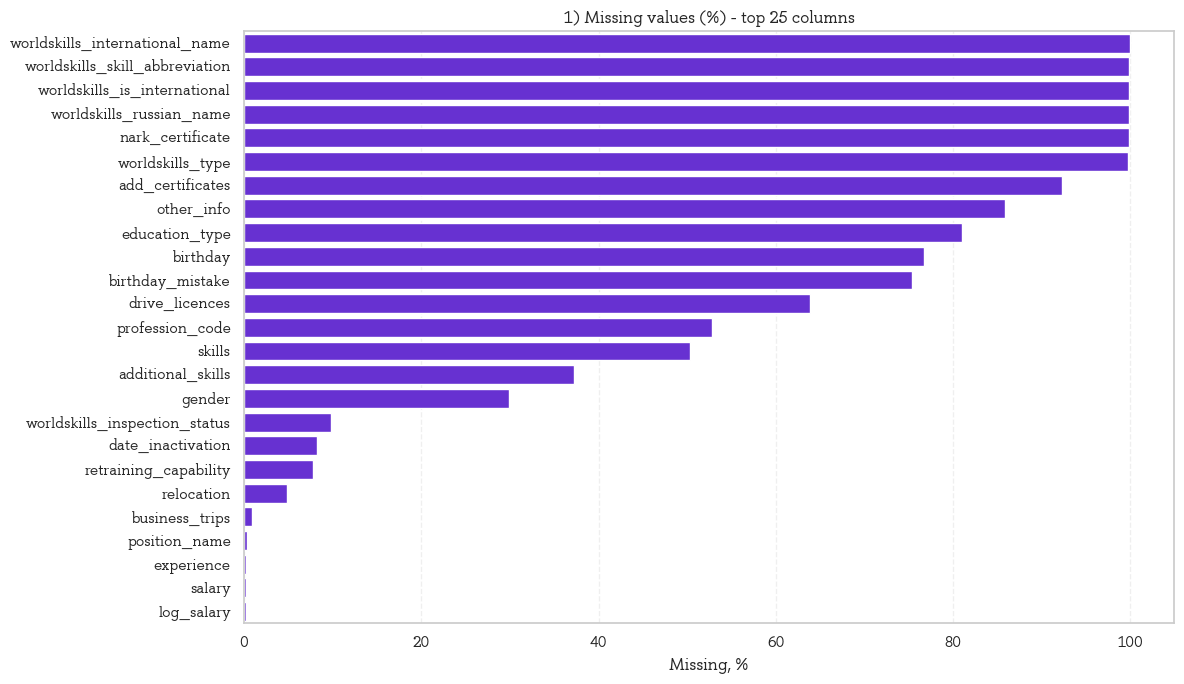

In [4]:
# 1. Missing Values Rate (Top 25 Columns)
na_rate = (plot_df.isna().mean().sort_values(ascending=False).head(25) * 100).reset_index()
na_rate.columns = ["column", "missing_pct"]

plt.figure(figsize=(12, 7))
sns.barplot(data=na_rate, y="column", x="missing_pct", color=PRIMARY)
plt.title("1) Missing values (%) - top 25 columns")
plt.xlabel("Missing, %")
plt.ylabel("")
plt.tight_layout()
plt.show()

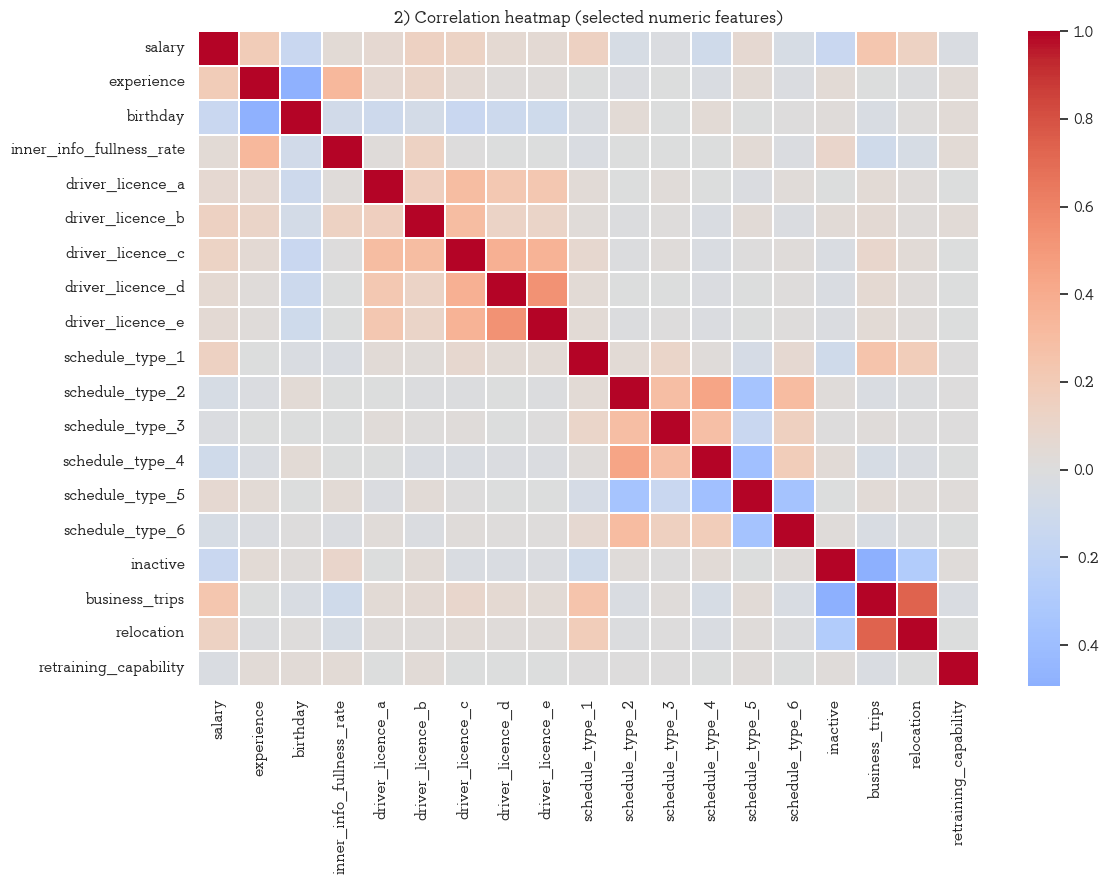

In [5]:
# 2. Numeric Correlation Heatmap
num_cols = [
    "salary", "experience", "birthday", "inner_info_fullness_rate",
    "driver_licence_a", "driver_licence_b", "driver_licence_c",
    "driver_licence_d", "driver_licence_e",
    "schedule_type_1", "schedule_type_2", "schedule_type_3",
    "schedule_type_4", "schedule_type_5", "schedule_type_6",
    "inactive", "business_trips", "relocation", "retraining_capability"
]
num_cols = [c for c in num_cols if c in plot_df.columns]
corr = plot_df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("2) Correlation heatmap (selected numeric features)")
plt.tight_layout()
plt.show()

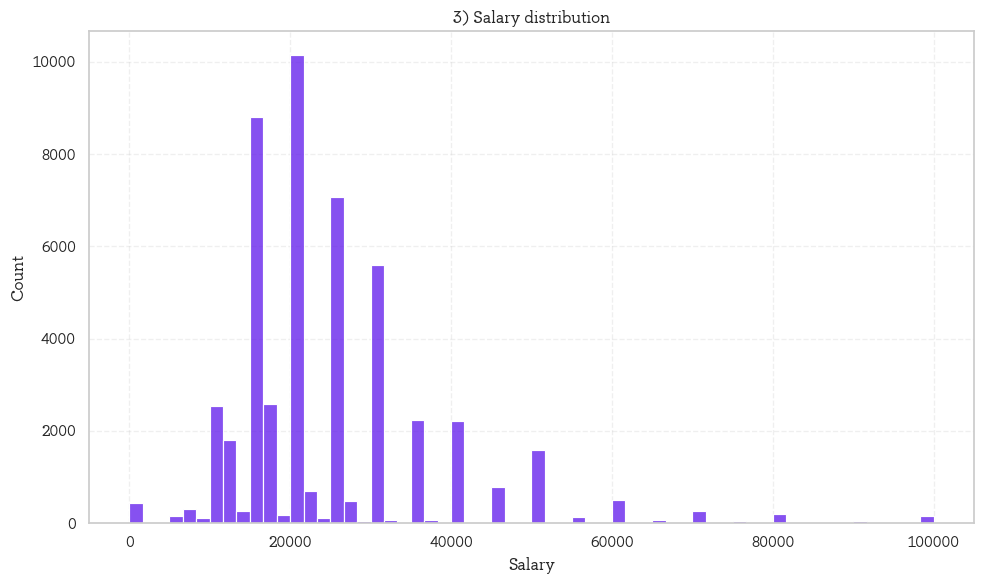

In [6]:
# 3. Salary Distribution (Histogram)
plt.figure(figsize=(10, 6))
sns.histplot(data=plot_df, x="salary", bins=60, kde=True, color=PRIMARY)
plt.title("3) Salary distribution")
plt.xlabel("Salary")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
# 4. Salary Distribution (KDE, log scale)
plt.figure(figsize=(10, 6))
sns.kdeplot(data=plot_df.dropna(subset=["log_salary"]), x="log_salary", fill=True, color=SECONDARY)
plt.title("4) Log-salary KDE")
plt.xlabel("log1p(salary)")
plt.tight_layout()
plt.show()

In [ ]:
# 5. Salary Boxplot
plt.figure(figsize=(10, 2.5))
sns.boxplot(data=plot_df, x="salary", color=PRIMARY)
plt.title("5) Salary boxplot")
plt.xlabel("Salary")
plt.tight_layout()
plt.show()

In [ ]:
# 6. Experience Distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=plot_df, x="experience", bins=40, kde=True, color=ACCENT)
plt.title("6) Experience distribution")
plt.xlabel("Experience")
plt.tight_layout()
plt.show()

In [ ]:
# 7. Experience KDE
plt.figure(figsize=(10, 6))
sns.kdeplot(data=plot_df.dropna(subset=["experience"]), x="experience", fill=True, color=PRIMARY)
plt.title("7) Experience KDE")
plt.xlabel("Experience")
plt.tight_layout()
plt.show()

In [ ]:
# 8. Experience vs Salary (Scatter + Regression)
sub = plot_df.dropna(subset=["experience", "salary"])
if len(sub) > 10000:
    sub = sub.sample(10000, random_state=42)

plt.figure(figsize=(10, 6))
sns.regplot(data=sub, x="experience", y="salary", scatter_kws={"alpha": 0.15, "s": 20}, line_kws={"color": SECONDARY})
plt.title("8) Experience vs salary")
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.tight_layout()
plt.show()

In [ ]:
# 9. Experience vs Salary (2D density)
plt.figure(figsize=(10, 6))
sns.histplot(data=plot_df, x="experience", y="salary", bins=40, pmax=0.95, cbar=True)
plt.title("9) 2D density: experience vs salary")
plt.tight_layout()
plt.show()

In [ ]:
# 10. Mean Salary by Experience
line_df = plot_df.dropna(subset=["experience", "salary"]).copy()
line_df = line_df.groupby("experience", as_index=False)["salary"].mean().sort_values("experience")

plt.figure(figsize=(10, 6))
sns.lineplot(data=line_df, x="experience", y="salary", color=PRIMARY)
plt.title("10) Mean salary by experience")
plt.xlabel("Experience")
plt.ylabel("Mean salary")
plt.tight_layout()
plt.show()

In [ ]:
# 11. Salary by Gender (Boxplot)
sub = plot_df.dropna(subset=["gender", "salary"]).copy()
plt.figure(figsize=(10, 6))
sns.boxplot(data=sub, x="gender", y="salary")
plt.title("11) Salary by gender")
plt.xlabel("Gender")
plt.ylabel("Salary")
plt.tight_layout()
plt.show()

In [ ]:
# 12. Gender Distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=plot_df, x="gender", order=plot_df["gender"].value_counts(dropna=False).index)
plt.title("12) Gender distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
# 13. Education Type Distribution (Top 10)
top_edu = plot_df["education_type"].fillna("NA").value_counts().head(10).index
sub = plot_df[plot_df["education_type"].fillna("NA").isin(top_edu)].copy()
sub["education_type"] = sub["education_type"].fillna("NA")

plt.figure(figsize=(12, 6))
sns.countplot(data=sub, y="education_type", order=top_edu)
plt.title("13) Education type distribution (top 10)")
plt.xlabel("Count")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [ ]:
# 14. Salary by Education Type (Top 8)
valid = plot_df.dropna(subset=["education_type", "salary"]).copy()
order = valid["education_type"].value_counts().head(8).index
valid = valid[valid["education_type"].isin(order)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=valid, y="education_type", x="salary", order=order)
plt.title("14) Salary by education type (top 8)")
plt.xlabel("Salary")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [ ]:
# 15. Busy Type Distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=plot_df, y="busy_type", order=plot_df["busy_type"].value_counts().index)
plt.title("15) Busy type distribution")
plt.xlabel("Count")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [ ]:
# 16. Salary by Busy Type
sub = plot_df.dropna(subset=["busy_type", "salary"]).copy()
order = sub["busy_type"].value_counts().index

plt.figure(figsize=(10, 6))
sns.boxplot(data=sub, y="busy_type", x="salary", order=order)
plt.title("16) Salary by busy type")
plt.xlabel("Salary")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [ ]:
# 17. Schedule Type Distribution (Top 10)
sub = plot_df.copy()
sub["schedule_type"] = sub["schedule_type"].fillna("NA")
order = sub["schedule_type"].value_counts().head(10).index
sub = sub[sub["schedule_type"].isin(order)]

plt.figure(figsize=(12, 6))
sns.countplot(data=sub, y="schedule_type", order=order)
plt.title("17) Schedule type distribution (top 10)")
plt.xlabel("Count")
plt.ylabel("")
plt.tight_layout()
plt.show()

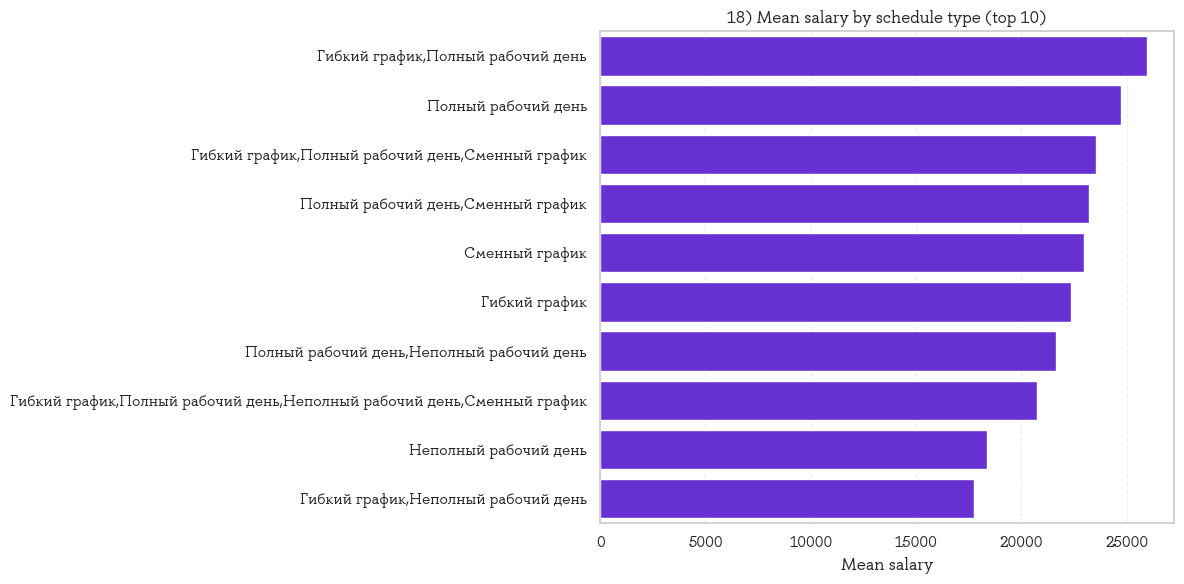

In [7]:
# 18. Mean Salary by Schedule Type (Top 10)
sub = plot_df.dropna(subset=["schedule_type", "salary"]).copy()
order = sub["schedule_type"].value_counts().head(10).index
sub = sub[sub["schedule_type"].isin(order)]
agg = sub.groupby("schedule_type", as_index=False)["salary"].mean().sort_values("salary", ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=agg, y="schedule_type", x="salary", color=PRIMARY)
plt.title("18) Mean salary by schedule type (top 10)")
plt.xlabel("Mean salary")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [ ]:
# 19. Inner Info Status Distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=plot_df, x="inner_info_status", order=plot_df["inner_info_status"].value_counts().index)
plt.title("19) Inner info status distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
# 20. Inner Info Fullness by Status
sub = plot_df.dropna(subset=["inner_info_status", "inner_info_fullness_rate"]).copy()

plt.figure(figsize=(10, 6))
sns.boxplot(data=sub, x="inner_info_status", y="inner_info_fullness_rate")
plt.title("20) Inner info fullness by status")
plt.xlabel("Status")
plt.ylabel("Fullness rate")
plt.tight_layout()
plt.show()

In [ ]:
# 21. Driver Licence Rate
lic_cols = [c for c in ["driver_licence_a", "driver_licence_b", "driver_licence_c", "driver_licence_d", "driver_licence_e"] if c in plot_df.columns]
lic_rate = plot_df[lic_cols].mean().mul(100).reset_index()
lic_rate.columns = ["licence", "pct_true"]

plt.figure(figsize=(9, 5))
sns.barplot(data=lic_rate, x="licence", y="pct_true", color=PRIMARY)
plt.title("21) Driver licence prevalence")
plt.xlabel("Licence")
plt.ylabel("Share, %")
plt.tight_layout()
plt.show()

In [ ]:
# 22. Schedule Flags Correlation Heatmap
sch_cols = [c for c in ["schedule_type_1", "schedule_type_2", "schedule_type_3", "schedule_type_4", "schedule_type_5", "schedule_type_6"] if c in plot_df.columns]
sch_corr = plot_df[sch_cols].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(sch_corr, annot=True, cmap="coolwarm", center=0)
plt.title("22) Correlation of schedule flags")
plt.tight_layout()
plt.show()

In [ ]:
# 23. Mobility Preferences Rate
mob_cols = [c for c in ["business_trips", "relocation", "retraining_capability"] if c in plot_df.columns]
mob = plot_df[mob_cols].mean().mul(100).reset_index()
mob.columns = ["feature", "pct_true"]

plt.figure(figsize=(9, 5))
sns.barplot(data=mob, x="feature", y="pct_true", palette=[PRIMARY, SECONDARY, ACCENT])
plt.title("23) Mobility-related preference rates")
plt.xlabel("")
plt.ylabel("Share, %")
plt.tight_layout()
plt.show()

In [ ]:
# 24. Inactive Flag Distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=plot_df, x="inactive")
plt.title("24) Inactive flag distribution")
plt.xlabel("Inactive")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
# 25. Salary by Inactive Flag
sub = plot_df.dropna(subset=["inactive", "salary"]).copy()
plt.figure(figsize=(8, 6))
sns.boxplot(data=sub, x="inactive", y="salary")
plt.title("25) Salary by inactive flag")
plt.xlabel("Inactive")
plt.ylabel("Salary")
plt.tight_layout()
plt.show()

In [ ]:
# 26. Vacancy Count by Weekday
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sub = plot_df.dropna(subset=["publish_weekday"]).copy()
agg = sub["publish_weekday"].value_counts().reindex(weekday_order).reset_index()
agg.columns = ["weekday", "count"]

plt.figure(figsize=(10, 5))
sns.lineplot(data=agg, x="weekday", y="count", marker="o", color=PRIMARY)
plt.title("26) Vacancy count by weekday")
plt.xlabel("Weekday")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
# 27. Median Salary by Weekday
sub = plot_df.dropna(subset=["publish_weekday", "salary"]).copy()
agg = sub.groupby("publish_weekday", as_index=False)["salary"].median()
agg["weekday"] = pd.Categorical(agg["publish_weekday"], categories=weekday_order, ordered=True)
agg = agg.sort_values("weekday")

plt.figure(figsize=(10, 5))
sns.lineplot(data=agg, x="publish_weekday", y="salary", marker="o", color=SECONDARY)
plt.title("27) Median salary by weekday")
plt.xlabel("Weekday")
plt.ylabel("Median salary")
plt.tight_layout()
plt.show()

In [ ]:
# 28. Vacancy Count by Month
sub = plot_df.dropna(subset=["publish_month"]).copy()
agg = sub["publish_month"].value_counts().sort_index().reset_index()
agg.columns = ["month", "count"]

plt.figure(figsize=(10, 5))
sns.barplot(data=agg, x="month", y="count", color=PRIMARY)
plt.title("28) Vacancy count by month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
# 29. Country Distribution (Top 15)
sub = plot_df.copy()
sub["country"] = sub["country"].fillna("NA")
order = sub["country"].value_counts().head(15).index
sub = sub[sub["country"].isin(order)]

plt.figure(figsize=(12, 6))
sns.countplot(data=sub, y="country", order=order)
plt.title("29) Country distribution (top 15)")
plt.xlabel("Count")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [ ]:
# 30. Top Position Names (Top 20)
sub = plot_df.copy()
sub["position_name"] = sub["position_name"].fillna("NA")
order = sub["position_name"].value_counts().head(20).index
sub = sub[sub["position_name"].isin(order)]

plt.figure(figsize=(12, 8))
sns.countplot(data=sub, y="position_name", order=order)
plt.title("30) Top position names (top 20)")
plt.xlabel("Count")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Notes for Next DANO Contest

- Keep this notebook as a template and swap only `DATA_PATH`.
- Add target-specific sections (feature engineering, drift checks, business metrics) when the next contest data is released.
- If needed, convert labels/titles to Russian for final report readiness.